In [22]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from scipy.signal import convolve2d
from sklearn.preprocessing import MinMaxScaler

# from mlp import Linear, MLP
from utils import discrete_2d_convolution

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# From a file (loaded as grayscale)
image_path = 'data/dog_painting.tiff'
image = np.array(Image.open(image_path).convert('L'))  # shape: [H, W], dtype: uint8

In [3]:
kernel_shape = (30, 30)
kernel_length = kernel_shape[0] * kernel_shape[1]
kernel_value = 1.0 / kernel_length
kernel = np.full(kernel_shape, kernel_value)
convolved_image = discrete_2d_convolution(image, kernel)

# naive implementation runs in 28.0s


<Figure size 1200x800 with 0 Axes>

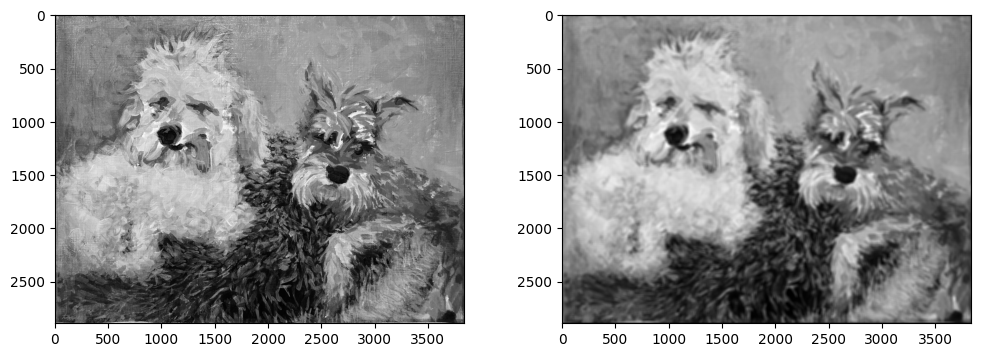

In [ ]:
plt.figure(figsize=(12, 8))
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

ax = axes[0]
ax.imshow(image, cmap='gray')

ax = axes[1]
ax.imshow(convolved_image, cmap='gray')

In [5]:
print(image.shape)
print(convolved_image.shape)

(2890, 3841)
(2890, 3841)


In [6]:
sci_convolved_image = convolve2d(image, kernel)

In [ ]:
def create_sobel_kernels(width):
    if width % 2 == 0:
        raise ValueError("Width must be an odd integer (e.g., 3, 5, 7, 9).")

    # 1. Create the Smoothing Vector (Binomial Coefficients / Pascal's Triangle)
    # For width 3, this is [1, 2, 1]. For width 9, it follows a bell curve.
    base = np.array([1, 1])
    smoothing = base.copy()
    for _ in range(width - 2):
        smoothing = np.convolve(smoothing, base)
    
    # 2. Create the Derivative Vector
    # This represents the change (gradient).
    derivative = np.zeros(width)
    center = width // 2
    for i in range(width):
        derivative[i] = i - center
        
    # 3. Create Kernels via Outer Product
    # Vertical Kernel (detects horizontal changes)
    # We smooth vertically and take the derivative horizontally
    sobel_x = np.outer(smoothing, derivative)
    
    # Horizontal Kernel (detects vertical changes)
    # We smooth horizontally and take the derivative vertically
    sobel_y = np.outer(derivative, smoothing)
    
    return sobel_x, sobel_y

# Generate 9x9 Kernels


In [42]:
def high_contrast(img):
    return np.abs(img)

In [17]:
kernel_vertical_9, kernel_horizontal_9 = create_sobel_kernels(9)
convolved_image_vertical_9 = discrete_2d_convolution(image, kernel_vertical_9)
convolved_image_horizontal_9 = discrete_2d_convolution(image, kernel_horizontal_9)

Text(0.5, 1.0, 'horizontal Edges')

<Figure size 1200x800 with 0 Axes>

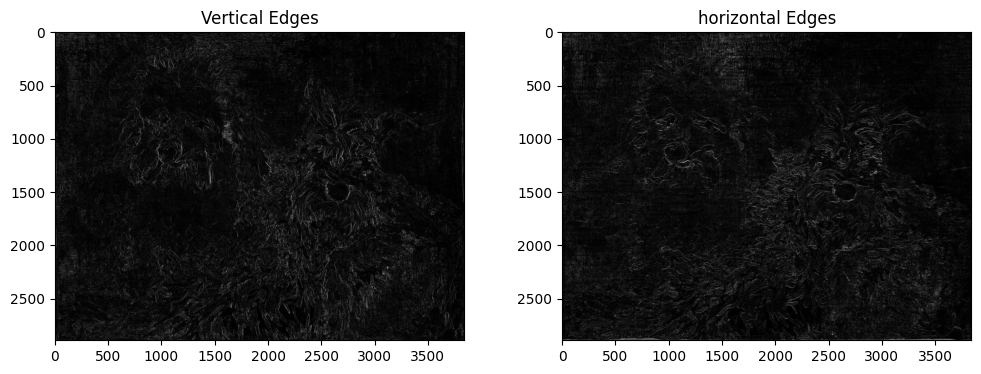

In [43]:
plt.figure(figsize=(12, 8))
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

ax = axes[0]
ax.imshow(high_contrast(convolved_image_vertical_9), cmap='gray')
ax.set_title('Vertical Edges')

ax = axes[1]
ax.imshow(high_contrast(convolved_image_horizontal_9), cmap='gray')
ax.set_title('horizontal Edges')

In [20]:
kernel_vertical_3, kernel_horizontal_3 = create_sobel_kernels(3)
convolved_image_vertical_3 = discrete_2d_convolution(image, kernel_vertical_3)
convolved_image_horizontal_3 = discrete_2d_convolution(image, kernel_horizontal_3)

Text(0.5, 1.0, 'horizontal Edges')

<Figure size 1200x800 with 0 Axes>

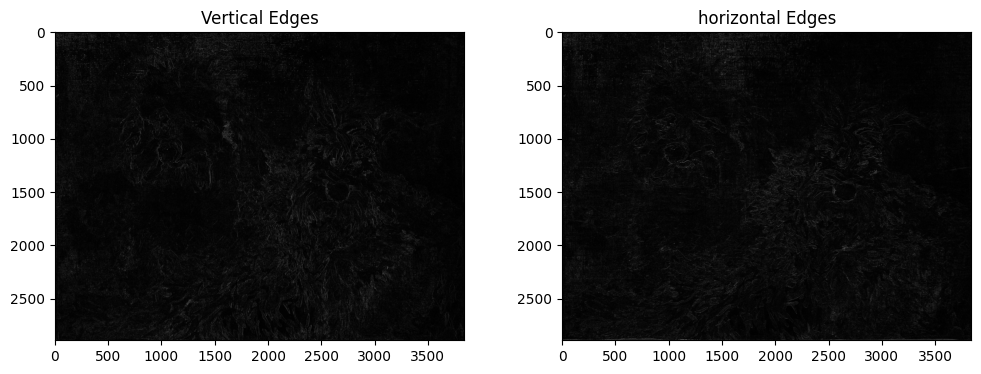

In [44]:
plt.figure(figsize=(12, 8))
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

ax = axes[0]
ax.imshow(high_contrast(convolved_image_vertical_3), cmap='gray')
ax.set_title('Vertical Edges')

ax = axes[1]
ax.imshow(high_contrast(convolved_image_horizontal_3), cmap='gray')
ax.set_title('horizontal Edges')

In [37]:
np.max(convolved_image_horizontal_3)
np.min(convolved_image_horizontal_3)

np.float64(-887.0)